In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

In [3]:
train_df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

In [4]:
train_df.head()
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
test_df.head()
test_df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

# Handling Missing Values

I have observed that the 'Cabin' feature in train_df, which consists of 891 samples, has 687 null values — that is, 77% of the values are missing. Similarly, 78% of the values in test_df are NaN for the same feature. So I decided to drop 'Cabin' from the dataset, as it won't contribute meaningfully to my model

In [6]:
print(test_df.shape)
train_df.shape


(418, 11)


(891, 12)

In [7]:
train_df["isTrain"] = 1
test_df["isTrain"] = 0

In [8]:
df = pd.concat([train_df, test_df], axis = 0, ignore_index = True)

In [9]:
print(df.shape)
df

(1309, 13)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,isTrain
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,0
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,0
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,0


In [10]:
df.isnull().sum()


PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
isTrain           0
dtype: int64

In [11]:
cat_imp = SimpleImputer(strategy = "most_frequent")
num_imp = SimpleImputer(strategy = "mean")

df[["Age"]] = num_imp.fit_transform(df[["Age"]])
df[["Embarked"]] = cat_imp.fit_transform(df[["Embarked"]])

train_df[["Age"]] = num_imp.fit_transform(train_df[["Age"]])
train_df[["Embarked"]] = cat_imp.fit_transform(train_df[["Embarked"]])

In [12]:
df[["Fare"]] = num_imp.fit_transform(df[["Fare"]])

# EDA and Feature Engineering


In [13]:
train_df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [14]:
col = ["Cabin", "Ticket", "PassengerId", "Name"]
df = df.drop(columns = col)
train_df = train_df.drop(columns = col)

In [15]:
df.shape

(1309, 9)

In [16]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,isTrain
0,0.0,3,male,22.0,1,0,7.2500,S,1
1,1.0,1,female,38.0,1,0,71.2833,C,1
2,1.0,3,female,26.0,0,0,7.9250,S,1
3,1.0,1,female,35.0,1,0,53.1000,S,1
4,0.0,3,male,35.0,0,0,8.0500,S,1


<Axes: xlabel='Embarked', ylabel='Count'>

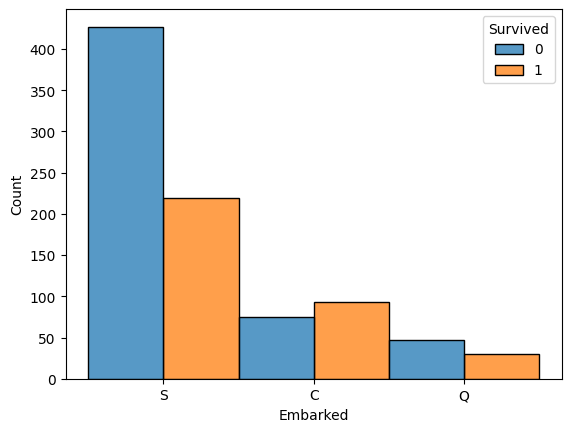

In [17]:
sns.histplot(train_df, x = "Embarked", hue = "Survived", multiple = "dodge")

In [18]:
train_df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: xlabel='Pclass', ylabel='Count'>

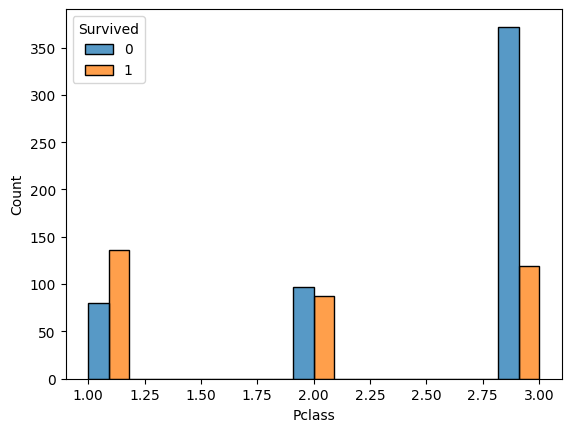

In [19]:
sns.histplot(train_df, x = "Pclass", hue = "Survived", multiple = "dodge")

<Axes: xlabel='Survived', ylabel='Fare'>

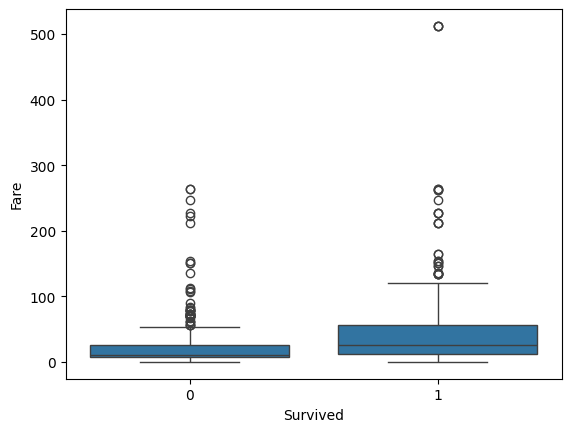

In [20]:
sns.boxplot(train_df, x = "Survived", y = "Fare")

<Axes: xlabel='Fare', ylabel='Count'>

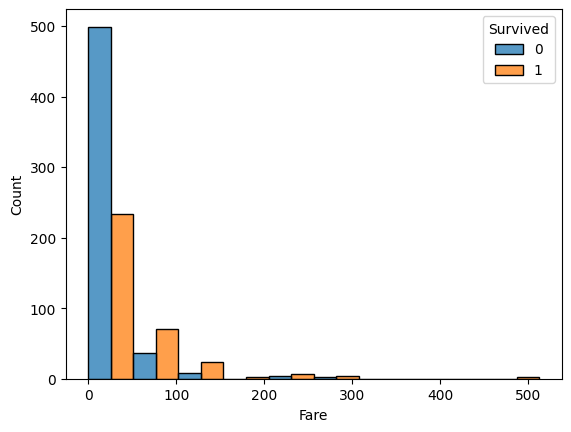

In [21]:
sns.histplot(train_df, x = "Fare", hue = "Survived", multiple = "dodge", bins = 10)

<Axes: xlabel='Age', ylabel='Count'>

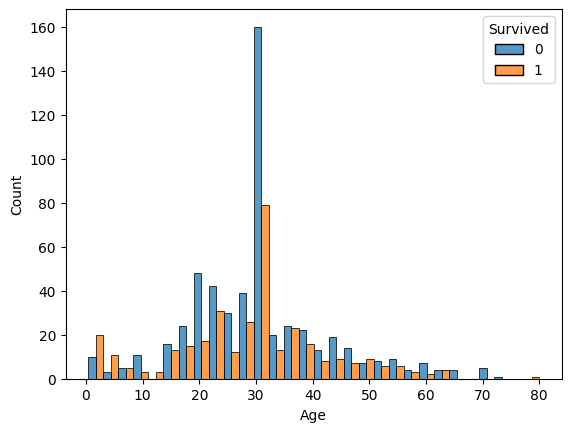

In [22]:
sns.histplot(train_df, x = "Age", hue = "Survived", multiple = "dodge")

<Axes: xlabel='Sex', ylabel='Count'>

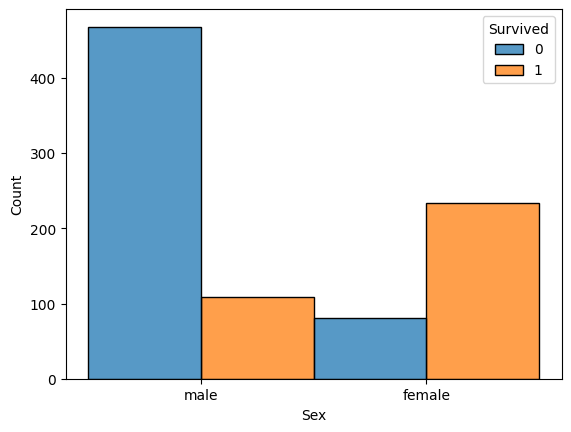

In [23]:
sns.histplot(train_df, x = "Sex", hue = "Survived", multiple = "dodge")

from the above plot we can say that if a person is female then she has higher chances of surviving

<Axes: xlabel='Parch', ylabel='Count'>

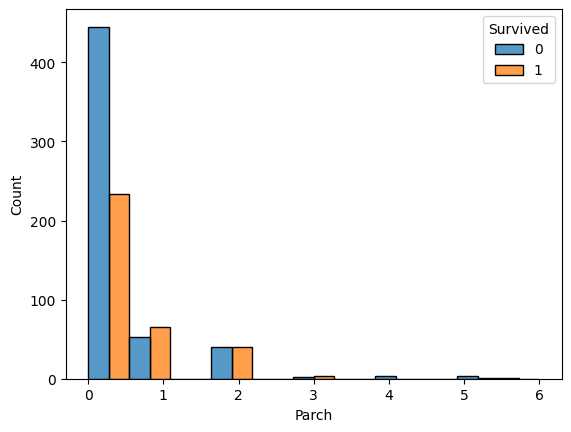

In [24]:
sns.histplot(train_df, x = "Parch", hue = "Survived", multiple = "dodge")

<Axes: xlabel='SibSp', ylabel='Count'>

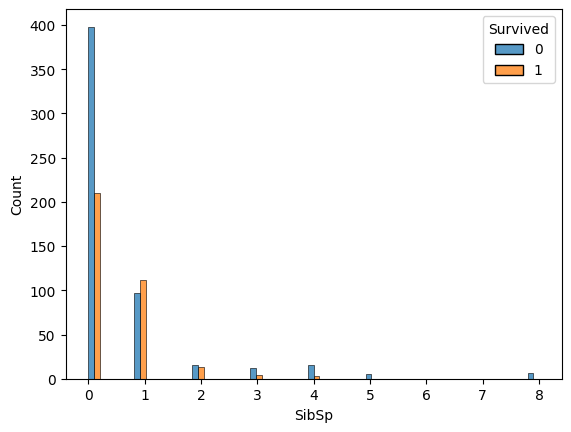

In [25]:
sns.histplot(train_df, x = "SibSp", hue = "Survived", multiple = "dodge")

# Encoding the data

In [26]:
ohe = OneHotEncoder(drop = "first", sparse_output = False)
cols = ["Sex", "Embarked"]
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols), index = df.index)

df = pd.concat([df.drop(columns = cols), encoded_df], axis = 1)


encoded_train = ohe.fit_transform(train_df[cols])
encoded_df_train = pd.DataFrame(encoded_train, columns = ohe.get_feature_names_out(cols), index = train_df.index)

train_df = pd.concat([train_df.drop(columns = cols), encoded_df_train], axis = 1)

<Axes: >

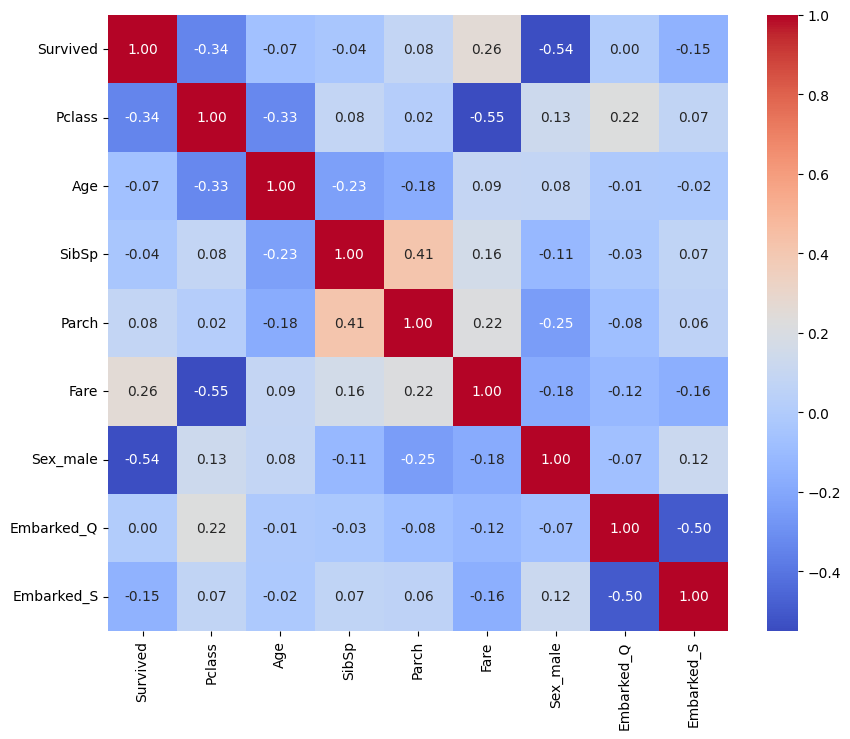

In [27]:
train_df = train_df.drop(columns = ["isTrain"])
num_cols = train_df.select_dtypes(include = "number")


corr_matrix = num_cols.corr()
plt.figure(figsize = (10, 8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

# splitting train_df and test_df from df

In [28]:
train_df_final = df[df["isTrain"] == 1].drop(columns = ["isTrain"])
test_df_final = df[df["isTrain"] == 0].drop(columns = ["isTrain"])

In [29]:
train_df_final.shape

(891, 9)

In [30]:
test_df_final = test_df_final.drop(columns = ["Survived"])

In [31]:
test_df_final

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
891,3,34.500000,0,0,7.8292,1.0,1.0,0.0
892,3,47.000000,1,0,7.0000,0.0,0.0,1.0
893,2,62.000000,0,0,9.6875,1.0,1.0,0.0
894,3,27.000000,0,0,8.6625,1.0,0.0,1.0
895,3,22.000000,1,1,12.2875,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
1304,3,29.881138,0,0,8.0500,1.0,0.0,1.0
1305,1,39.000000,0,0,108.9000,0.0,0.0,0.0
1306,3,38.500000,0,0,7.2500,1.0,0.0,1.0
1307,3,29.881138,0,0,8.0500,1.0,0.0,1.0


# splitting the training data 

In [32]:
X = train_df_final.drop(columns = ["Survived"])
y = train_df_final["Survived"]

In [33]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

# Decision Tree Classifier

In [34]:
model = DecisionTreeClassifier(max_depth = 6)

model.fit(X_train_full, y_train_full)
y_pred = model.predict(X_test)

print("acc : ", accuracy_score(y_test, y_pred))

acc :  0.8044692737430168


In [35]:
depths = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

for depth in depths :
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train_full, y_train_full)
    y_pred = model.predict(X_test)

    print(f"depth : {depth} ; acc : {accuracy_score(y_test, y_pred)}")

depth : 2 ; acc : 0.7653631284916201
depth : 3 ; acc : 0.7988826815642458
depth : 4 ; acc : 0.7988826815642458
depth : 5 ; acc : 0.7988826815642458
depth : 6 ; acc : 0.8044692737430168
depth : 7 ; acc : 0.8044692737430168
depth : 8 ; acc : 0.7821229050279329
depth : 9 ; acc : 0.7932960893854749
depth : 10 ; acc : 0.7877094972067039
depth : 11 ; acc : 0.7877094972067039
depth : 12 ; acc : 0.7877094972067039


# Random Forest

In [36]:
rf = RandomForestClassifier(
    n_estimators = 301,
    max_depth = 6, 
    oob_score = True
)

rf.fit(X_train_full, y_train_full)

y_pred = rf.predict(X_test)

print("acc : ", accuracy_score(y_test, y_pred))

acc :  0.8044692737430168


# ANN

## scaling the data

In [37]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size = 0.15, random_state = 42
)

In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

## converting data into tensors

In [39]:
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

## Tensor Dataset and DataLoader

In [40]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

In [41]:
train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 16)
val_loader = DataLoader(val_dataset, batch_size = 16)

## Defining the model

In [42]:
class ANN(nn.Module) :
    def __init__(self) :
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 16),
            nn.ReLU(),

            #2nd hidden layer
            nn.Linear(16, 16),
            nn.ReLU(),

            #output layer
            nn.Linear(16, 1)
        )

    def forward(self, X) :
        return self.model(X)

creating model, criterion and optimizers

In [43]:
model = ANN()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters())

## Training the model

In [44]:
epochs = 100
training_loss = []
validation_loss = []
best_val_loss = float("inf")

for epoch in range(epochs) :
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader :
        optimizer.zero_grad()

        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    
    epoch_train_loss = running_loss/len(train_loader)
    training_loss.append(epoch_train_loss)

    #validation
    model.eval()
    
    running_val_loss = 0.0
    with torch.no_grad() :
        for xb, yb in val_loader :
            outputs = model(xb)
            loss = criterion(outputs, yb)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss/len(val_loader)
    validation_loss.append(epoch_val_loss)

    #print(f"epoch = {epoch + 1}/{epochs} ==> training loss : {epoch_train_loss} , validation loss {epoch_val_loss}")
    
    if epoch_val_loss < best_val_loss :
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

## visualization of losses

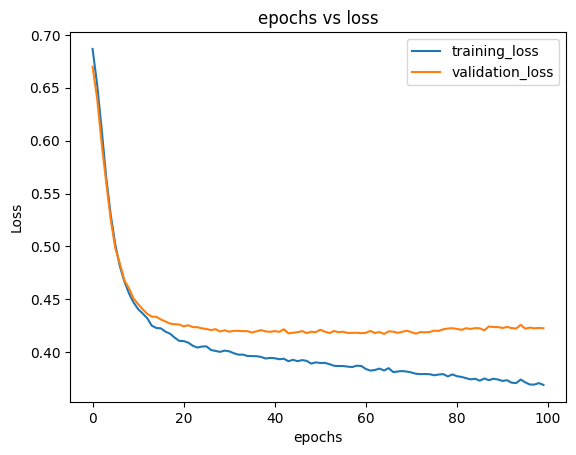

In [45]:
plt.plot(training_loss, label = "training_loss")
plt.plot(validation_loss, label = "validation_loss")
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.title("epochs vs loss")
plt.legend()

In [46]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [47]:
model.eval()
total = 0
correct = 0

with torch.no_grad():
    for xb, yb in val_loader:
        outputs = model(xb)
        probs = torch.sigmoid(outputs)
        predicted = (probs >= 0.5).float()

        correct += (predicted == yb).sum().item()
        total += yb.size(0)

print("total predicted val number : ", total)
print("Correctly predicted val number : ", correct)
print("accuracy score : ", correct/total * 100)

total predicted val number :  107
Correctly predicted val number :  90
accuracy score :  84.11214953271028


In [48]:
model.eval()
total = 0
correct = 0

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        probs = torch.sigmoid(outputs)
        predicted = (probs >= 0.5).float()

        correct += (predicted == yb).sum().item()
        total += yb.size(0)

print("total predicted val number : ", total)
print("Correctly predicted val number : ", correct)
print("accuracy score : ", correct/total * 100)

total predicted val number :  179
Correctly predicted val number :  146
accuracy score :  81.56424581005587


# submission of best Model

In [49]:
test_scaled_final = scaler.transform(test_df_final)
test_tensor_final = torch.tensor(test_scaled_final, dtype = torch.float32)

test_final_dataset = TensorDataset(test_tensor_final)
test_final_loader = DataLoader(test_final_dataset, batch_size = 16, shuffle = False)

In [50]:
model.eval()
survived = []

for (xb, ) in test_final_loader :
    outputs = model(xb)
    probs = torch.sigmoid(outputs)
    predicted = (probs >= 0.5).float()
    
    survived.append(predicted)

survived = torch.cat(survived).numpy().flatten()

In [51]:
# submission1 = pd.DataFrame({
#     "PassengerId": test_df["PassengerId"],
#     "Survived": survived.astype(int)
# })

# submission1.to_csv("submission.csv", index=False)
# submission1.head()

In [52]:
print(np.unique(survived, return_counts=True))

(array([0., 1.], dtype=float32), array([284, 134]))


In [53]:
#submission1["Survived"].value_counts()

In [54]:
test_pred_final = rf.predict(test_df_final)

In [55]:
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_pred_final.astype(int)
})

submission.to_csv("submission.csv", index=False)
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [56]:
print(np.unique(survived, return_counts=True))

(array([0., 1.], dtype=float32), array([284, 134]))


In [57]:
submission["Survived"].value_counts()

Survived
0    285
1    133
Name: count, dtype: int64